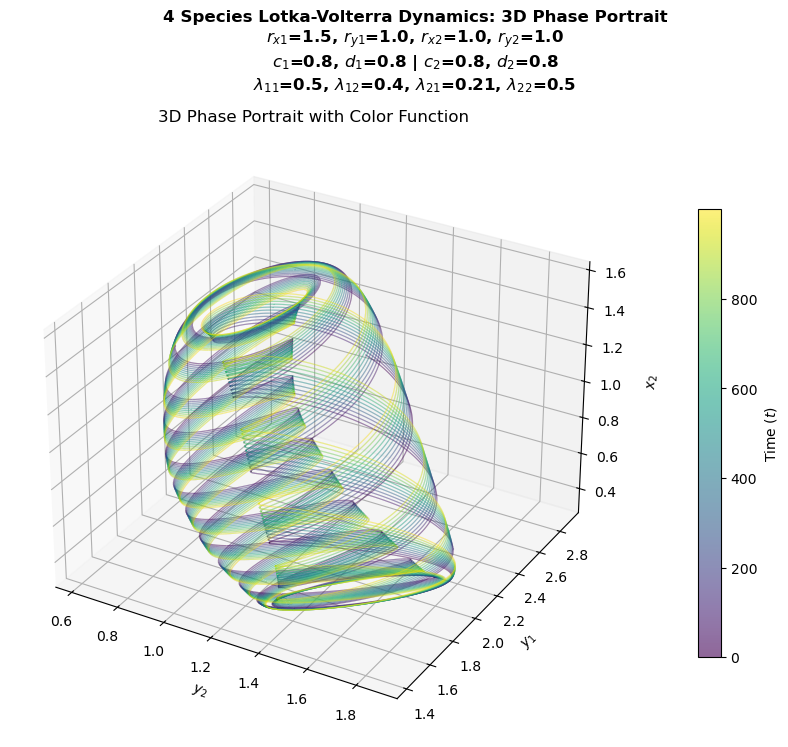

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D # 3Dプロット用のインポート
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import Normalize

# 1. モデル方程式の定義
def model(z, t, params):
    x1, y1, x2, y2 = z
    r_x1, r_y1, r_x2, r_y2 = params['r']
    lam = params['lambda'] # 行列 [[l11, l12], [l21, l22]]
    c = params['c']
    d = params['d']
    
    # 係数の展開
    l11, l12 = lam[0]
    l21, l22 = lam[1]
    c1, c2 = c
    d1, d2 = d
    
    
    dx1dt = r_x1*x1 - l11*x1*y1 - l12*x1*y2
    dx2dt = r_x2*x2 - l21*x2*y1 - l22*x2*y2

    # --- 捕食者 (Predator) の式: y1, y2 ---
    dy1dt = -r_y1*y1 + c1*l11*x1*y1 + d1*l21*x2*y1
    dy2dt = -r_y2*y2 + c2*l12*x1*y2 + d2*l22*x2*y2
    
    return [dx1dt, dy1dt, dx2dt, dy2dt]

# 2. パラメータ設定 (ユーザー指定の値を使用)
params = {
    'r': [1.5, 1.0, 1.0, 1.0],       
    'lambda': [[0.5, 0.4], 
               [0.21, 0.5]],   
    'c': [0.8, 0.8],
    'd': [0.8, 0.8]      
}

# 初期状態
z0 = [2.0, 2.0, 1.5, 1.5] # [x1, y1, x2, y2]

# 時間軸
t = np.linspace(0, 1000, 500000)

# 3. 微分方程式を解く
z = odeint(model, z0, t, args=(params,))

x1 = z[:, 0]
y1 = z[:, 1]
x2 = z[:, 2]
y2 = z[:, 3]

# パラメータの展開
r_list = params['r']
lambda_matrix = params['lambda']
c_list = params['c']
d_list = params['d']

# タイトル文字列の生成
full_title = (
    f'4 Species Lotka-Volterra Dynamics: 3D Phase Portrait\n'
    # rパラメータ
    f'$r_{{x1}}$={r_list[0]}, $r_{{y1}}$={r_list[1]}, $r_{{x2}}$={r_list[2]}, $r_{{y2}}$={r_list[3]}\n'
    # c, d パラメータ
    f'$c_1$={c_list[0]}, $d_1$={d_list[0]} | $c_2$={c_list[1]}, $d_2$={d_list[1]}\n'
    # lambda パラメータ
    f'$\\lambda_{{11}}$={lambda_matrix[0][0]}, $\\lambda_{{12}}$={lambda_matrix[0][1]}, $\\lambda_{{21}}$={lambda_matrix[1][0]}, $\\lambda_{{22}}$={lambda_matrix[1][1]}'
)


## 4. 可視化 (色関数バージョン)
fig = plt.figure(figsize=(9, 8)) # カラーバーの分だけ少し横長に

plt.suptitle(
    full_title,
    fontsize=12,
    fontweight='bold',
    y=0.98
)

ax = plt.subplot(1, 1, 1, projection='3d')

# --- データの準備 ---
# 座標データを結合して (N, 3) の形にする
points = np.array([y2, y1, x2]).T.reshape(-1, 1, 3)
# 隣り合う点を結んで「線分（セグメント）」の集まりを作る
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# --- 色付けの基準を決める ---
# ここでは「時間 t」を色の基準にします（Mathematicaの ColorFunction -> Function[t, ...] に相当）
# ※ 第4の変数 y2 を色にしたい場合は、color_data = y2[:-1] に変更してください
color_data = t[:-1] 

# --- コレクションの作成 ---
# norm: データの最小値〜最大値を 0〜1 に正規化
norm = Normalize(vmin=color_data.min(), vmax=color_data.max())

# Line3DCollectionを作成
lc = Line3DCollection(segments, cmap='viridis', norm=norm, alpha=0.6) # cmapはお好みで 'viridis', 'plasma', 'jet' など
lc.set_array(color_data)
lc.set_linewidth(0.8) # 線の太さ

# --- プロットに追加 ---
ax.add_collection(lc)

# 軸の範囲を手動で設定する必要があります（add_collectionは自動調整しないため）
ax.set_xlim(y2.min(), y2.max())
ax.set_ylim(y1.min(), y1.max())
ax.set_zlim(x2.min(), x2.max())

ax.set_xlabel('$y_2$')
ax.set_ylabel('$y_1$ ')
ax.set_zlabel('$x_2$ ', labelpad=10)
ax.set_title('3D Phase Portrait with Color Function')

ax.grid(True)

# --- カラーバーの追加 ---
# 時間の経過や値の大小が色でわかるようになります
cbar = plt.colorbar(lc, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Time ($t$)') # y2にする場合はラベルを変更

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.85)
plt.savefig("strangeattractorcycle11.png")
plt.show()

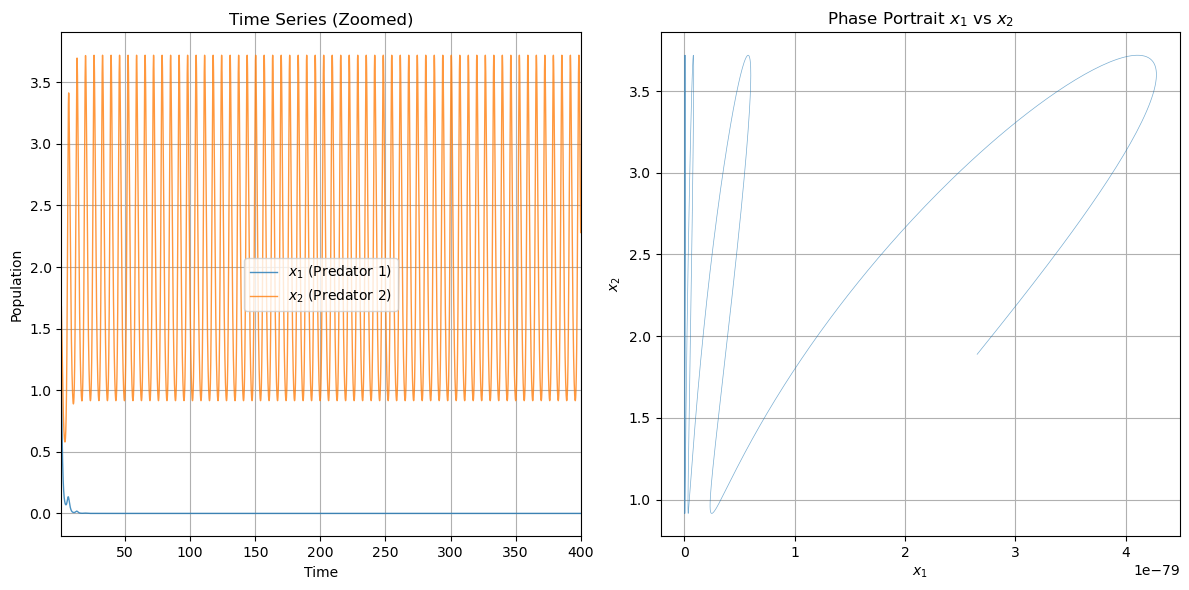

In [15]:
# --- 診断用コード：時系列と3Dの拡大 ---

fig2 = plt.figure(figsize=(12, 6))

# 1. 時系列データの確認 (x1 と x2 の比較)
# ここで「振幅が変動している（うなり）」なら、準周期解です
ax1 = fig2.add_subplot(1, 2, 1)
ax1.plot(t, x1, label='$x_1$ (Predator 1)', alpha=0.8, linewidth=1)
ax1.plot(t, x2, label='$x_2$ (Predator 2)', alpha=0.8, linewidth=1)
ax1.set_xlim(1, 400) # 後半の安定した部分だけ拡大
ax1.set_title('Time Series (Zoomed)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Population')
ax1.legend()
ax1.grid(True)

# 2. 軌道の断面を確認 (Poincare section的な視点)
# 3次元ではなく、あえて2次元で投影して「線の重なり」を見ます
ax2 = fig2.add_subplot(1, 2, 2)
# 後半のデータのみプロット（初期の乱れを除く）
start_idx = 30000 
ax2.plot(x1[start_idx:], x2[start_idx:], lw=0.5, alpha=0.6)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Phase Portrait $x_1$ vs $x_2$')
ax2.grid(True)

plt.tight_layout()
plt.show()